# Modélisation — Prédiction du Churn Client

Ce notebook constitue le second livrable : implémentation, comparaison et optimisation
de plusieurs modèles de classification pour prédire le churn, à partir des données
préparées dans le notebook précédent.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- Rechargement du train/test préparé dans le notebook de nettoyage ---
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

X_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]
X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]

print(X_train.shape, X_test.shape)

(5634, 19) (1409, 19)


In [2]:
# --- Palette cohérente, reprise du notebook de nettoyage (kernel séparé, on la redéfinit ici) ---
COULEUR_RESTE = "#2a78d6"
COULEUR_CHURN = "#eb6834"
PALETTE_CHURN = {0: COULEUR_RESTE, 1: COULEUR_CHURN}

## 1. Pipeline de préprocessing

Le préprocessing (normalisation des variables numériques, encodage one-hot des variables
catégorielles) est encapsulé dans un `Pipeline` scikit-learn avec le modèle, pour être
réappris uniquement sur les données d'entraînement à chaque pli de validation croisée —
seule protection structurelle contre la fuite de données.

In [3]:
# --- Pipeline de préprocessing, réutilisable pour tous les modèles de la semaine ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Détection automatique des colonnes numériques vs catégorielles
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()
print("Numériques :", num_cols)
print("Catégorielles :", cat_cols)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),        # normalisation, nécessaire pour la régression logistique
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),  # encodage des variables catégorielles
])

def make_model(clf):
    """Assemble le préprocessing et un classifieur dans un seul pipeline,
    pour garantir que le préprocessing est ré-appris uniquement sur les données d'entraînement
    à chaque validation croisée (évite toute fuite de données)."""
    return Pipeline([("prep", preprocess), ("clf", clf)])

Numériques : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Catégorielles : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 2. Modèle de référence (baseline)

Un `DummyClassifier` qui prédit toujours "reste" atteint 73,5 % d'accuracy — rappel du
piège classique sur données déséquilibrées : tout modèle sérieux doit être comparé à
cette référence, et pas seulement jugé sur l'accuracy.

In [4]:
# --- Baseline : un modèle "bête" pour avoir un point de comparaison ---
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print(f"Accuracy du dummy (prédit toujours 'reste') : {accuracy_score(y_test, dummy.predict(X_test)):.3f}")
# -> attendu ~0.735 : tout modèle sérieux doit largement dépasser ce chiffre

Accuracy du dummy (prédit toujours 'reste') : 0.735


## 3. Régression logistique

Premier modèle testé, conformément à l'étape 3 du brief. Évalué par matrice de confusion,
courbes ROC/AUC. **Résultat (test)** : AUC = 0,842, accuracy 81 % (contre 73,5 % pour le
dummy), rappel de la classe Churn = 0,56.

              precision    recall  f1-score   support

       Reste       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



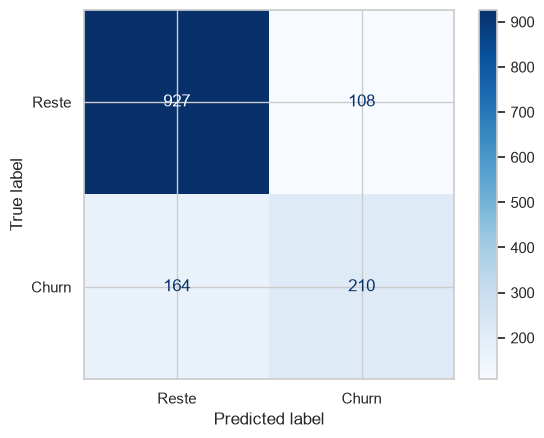

In [5]:
# --- Modèle 1 : Régression logistique ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

RANDOM_STATE = 42

logreg = make_model(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Reste", "Churn"]).plot(cmap="Blues")

print(classification_report(y_test, y_pred, target_names=["Reste", "Churn"]))

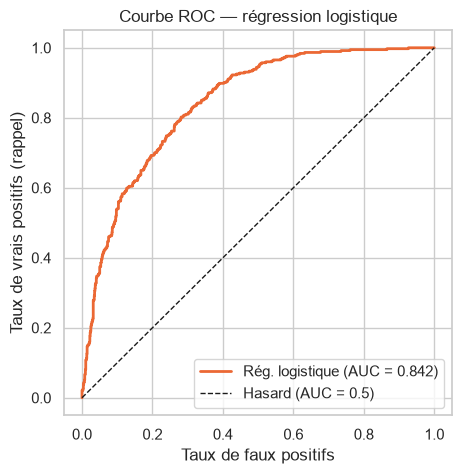

In [6]:
# --- Courbe ROC et AUC ---
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = logreg.predict_proba(X_test)[:, 1]  # probabilité de churn
fpr, tpr, seuils = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color=COULEUR_CHURN, linewidth=2, label=f"Rég. logistique (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Hasard (AUC = 0.5)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (rappel)")
plt.title("Courbe ROC — régression logistique")
plt.legend()
plt.show()

In [7]:
# --- Validation croisée stratifiée : mesure plus stable qu'un seul split ---
from sklearn.model_selection import StratifiedKFold, cross_validate

RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluer(model, nom, X=X_train, y=y_train, cv=cv):
    """Validation croisée multi-métriques d'un pipeline. Retourne une ligne de synthèse."""
    res = cross_validate(
        model, X, y, cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall", "accuracy"],
    )
    return {
        "modèle": nom,
        "AUC": f"{res['test_roc_auc'].mean():.3f} ± {res['test_roc_auc'].std():.3f}",
        "F1": f"{res['test_f1'].mean():.3f}",
        "précision": f"{res['test_precision'].mean():.3f}",
        "rappel": f"{res['test_recall'].mean():.3f}",
        "accuracy": f"{res['test_accuracy'].mean():.3f}",
    }

# Cette liste va s'enrichir à chaque nouveau modèle testé -> deviendra le tableau comparatif final
resultats = []
resultats.append(evaluer(make_model(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
                          "Rég. logistique (L2)"))
pd.DataFrame(resultats)

,modèle,AUC,F1,précision,rappel,accuracy
0,Rég. logistique (L2),0.846 ± 0.013,0.593,0.653,0.543,0.802


## 4. Comparaison avec d'autres modèles de régression

Comparaison de la régularisation L1 (Lasso) et L2 (Ridge), ainsi qu'un `SGDClassifier`
(même famille de modèle, optimisation par descente de gradient stochastique). **Résultat
(validation croisée)** : L1 et L2 quasi identiques (AUC 0,846) — la colinéarité
tenure/TotalCharges n'affecte pas la régression logistique standard. Le SGD fait
légèrement moins bien (0,836), un solveur exact étant préférable sur un dataset de cette
taille. **Conclusion : la régression logistique standard (L2) est bien adaptée**, aucune
variante testée ne l'améliore.

In [8]:
# --- Comparaison avec d'autres modèles de régression (linéaires) ---
from sklearn.linear_model import SGDClassifier

# Régression logistique avec régularisation L1 (Lasso) : met à zéro les coefficients
# des variables les moins utiles -> pertinent vu la colinéarité tenure/TotalCharges repérée en EDA
resultats.append(evaluer(make_model(
    LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000, random_state=RANDOM_STATE)),
    "Rég. logistique (L1)"))

# SGDClassifier avec perte logistique : même modèle mathématique, optimisation différente (descente
# de gradient stochastique) -> utile à comparer, notamment pour la scalabilité sur de gros volumes
resultats.append(evaluer(make_model(
    SGDClassifier(loss="log_loss", random_state=RANDOM_STATE)),
    "SGD (perte logistique)"))

pd.DataFrame(resultats)

c:\Users\prime\Desktop\BLOC-3\Bloc-3-Machine-Learning\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\prime\Desktop\BLOC-3\Bloc-3-Machine-Learning\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\prime\Desktop\BLOC-3\Bloc-3-Machine-Learning\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

,modèle,AUC,F1,précision,rappel,accuracy
0,Rég. logistique (L2),0.846 ± 0.013,0.593,0.653,0.543,0.802
1,Rég. logistique (L1),0.846 ± 0.012,0.593,0.653,0.544,0.802
2,SGD (perte logistique),0.836 ± 0.013,0.573,0.657,0.518,0.798


## 5. Arbre de décision

Deux versions comparées pour illustrer le compromis biais-variance : un arbre sans limite
de profondeur et un arbre contraint (`max_depth=5`). **Résultat** : l'arbre libre
s'effondre (AUC 0,663, à peine au-dessus du hasard) — il a surappris le bruit du jeu
d'entraînement. L'arbre contraint remonte à 0,829, proche de la régression logistique,
et reste interprétable (visualisation des règles de décision et des variables les plus
importantes ci-dessous).

In [9]:
# --- Arbre de décision : sans limite (référence) vs profondeur contrainte (interprétable) ---
from sklearn.tree import DecisionTreeClassifier, plot_tree

resultats.append(evaluer(make_model(DecisionTreeClassifier(random_state=RANDOM_STATE)),
                          "Arbre (sans limite)"))
resultats.append(evaluer(make_model(DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
                          "Arbre (max_depth=5)"))

pd.DataFrame(resultats)

,modèle,AUC,F1,précision,rappel,accuracy
0,Rég. logistique (L2),0.846 ± 0.013,0.593,0.653,0.543,0.802
1,Rég. logistique (L1),0.846 ± 0.012,0.593,0.653,0.544,0.802
2,SGD (perte logistique),0.836 ± 0.013,0.573,0.657,0.518,0.798
3,Arbre (sans limite),0.663 ± 0.017,0.504,0.500,0.508,0.734
4,Arbre (max_depth=5),0.829 ± 0.011,0.577,0.618,0.542,0.790


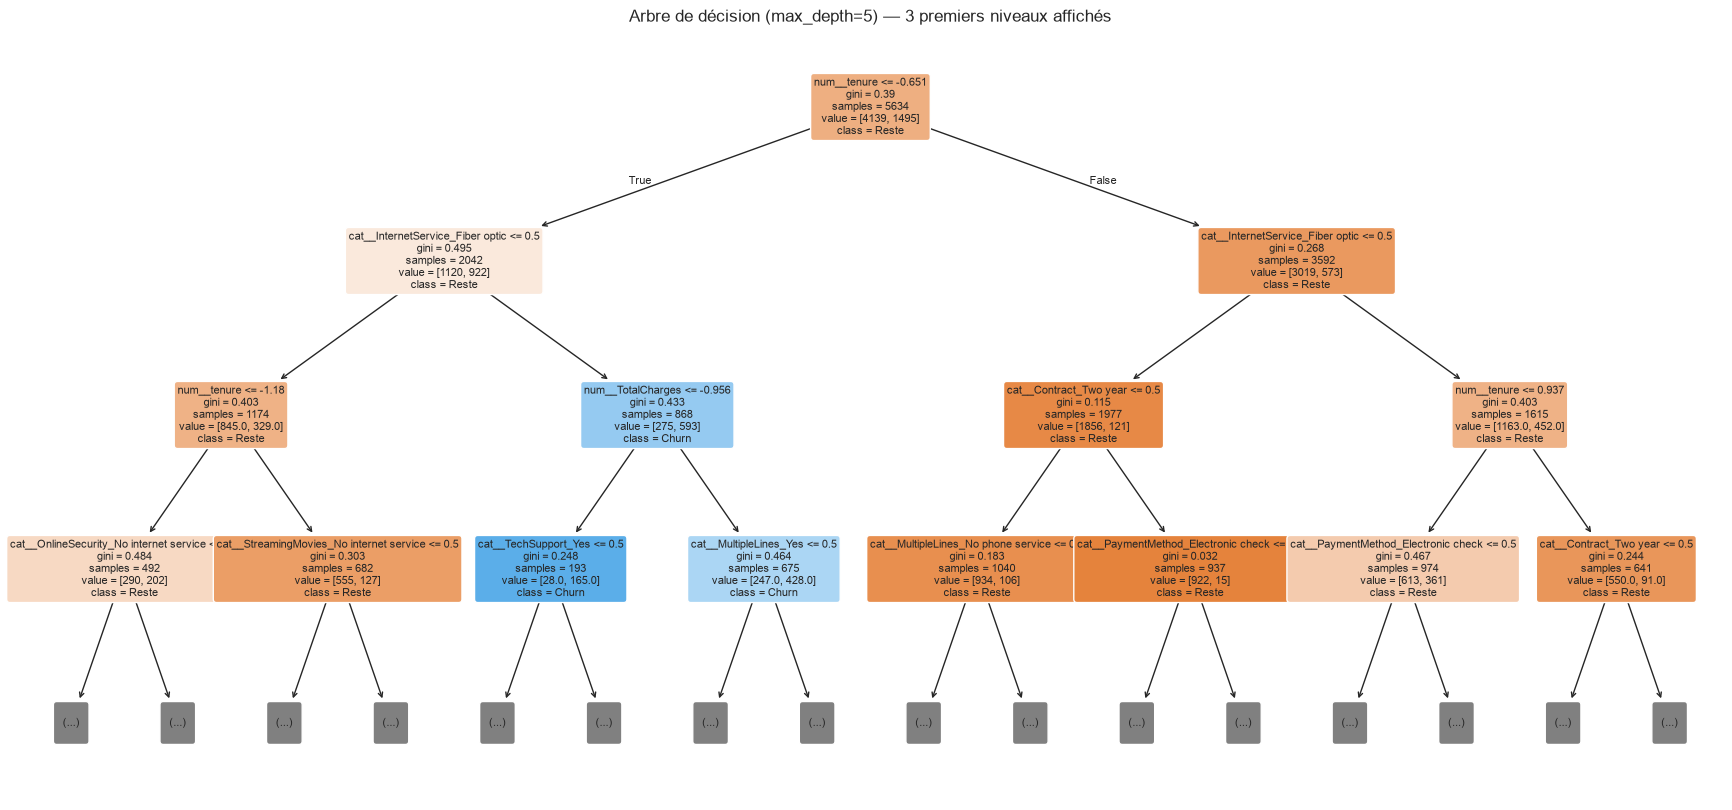

In [10]:
# --- Interprétation : visualisation de l'arbre contraint (max_depth=5) ---
# On entraîne une version "autonome" (hors pipeline CV) juste pour la visualisation et l'analyse
arbre_interpretable = make_model(DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))
arbre_interpretable.fit(X_train, y_train)

# Récupération des noms de colonnes après encodage (nécessaire pour lire l'arbre)
noms_colonnes = arbre_interpretable.named_steps["prep"].get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(
    arbre_interpretable.named_steps["clf"],
    feature_names=noms_colonnes,
    class_names=["Reste", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,  # on affiche seulement les 3 premiers niveaux pour la lisibilité
)
plt.title("Arbre de décision (max_depth=5) — 3 premiers niveaux affichés")
plt.show()

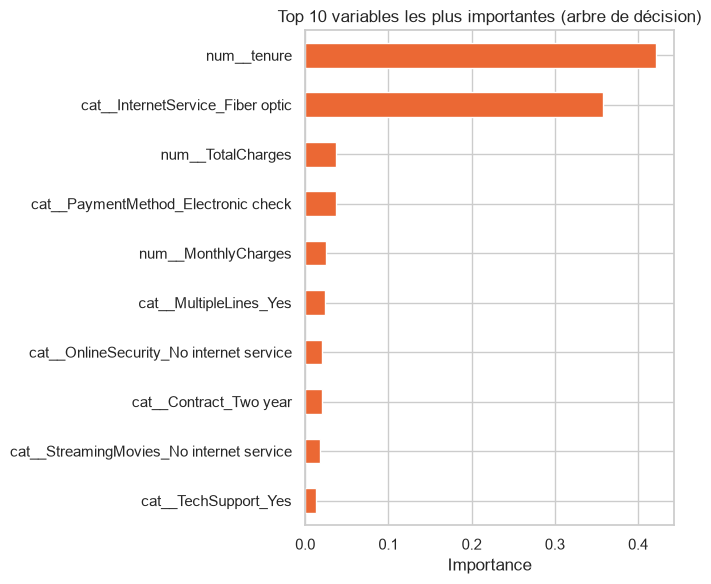

In [11]:
# --- Importance des variables selon l'arbre ---
importances = pd.Series(
    arbre_interpretable.named_steps["clf"].feature_importances_,
    index=noms_colonnes,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
importances.head(10).plot(kind="barh", ax=ax, color=COULEUR_CHURN)
ax.invert_yaxis()
ax.set_title("Top 10 variables les plus importantes (arbre de décision)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 6. Random Forest

Combine de nombreux arbres profonds pour réduire la variance individuelle des arbres
sans sacrifier leur faible biais. **Résultat par défaut** : AUC 0,827 — pas meilleur
qu'un arbre seul contraint, signe que les hyperparamètres par défaut ne sont pas
optimaux (notamment l'absence de pondération des classes).

In [12]:
# --- Random Forest : combine de nombreux arbres profonds décorrélés ---
from sklearn.ensemble import RandomForestClassifier

resultats.append(evaluer(make_model(
    RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    "Random Forest (défaut)"))

pd.DataFrame(resultats)

,modèle,AUC,F1,précision,rappel,accuracy
0,Rég. logistique (L2),0.846 ± 0.013,0.593,0.653,0.543,0.802
1,Rég. logistique (L1),0.846 ± 0.012,0.593,0.653,0.544,0.802
2,SGD (perte logistique),0.836 ± 0.013,0.573,0.657,0.518,0.798
3,Arbre (sans limite),0.663 ± 0.017,0.504,0.500,0.508,0.734
4,Arbre (max_depth=5),0.829 ± 0.011,0.577,0.618,0.542,0.790
5,Random Forest (défaut),0.827 ± 0.012,0.544,0.637,0.476,0.789


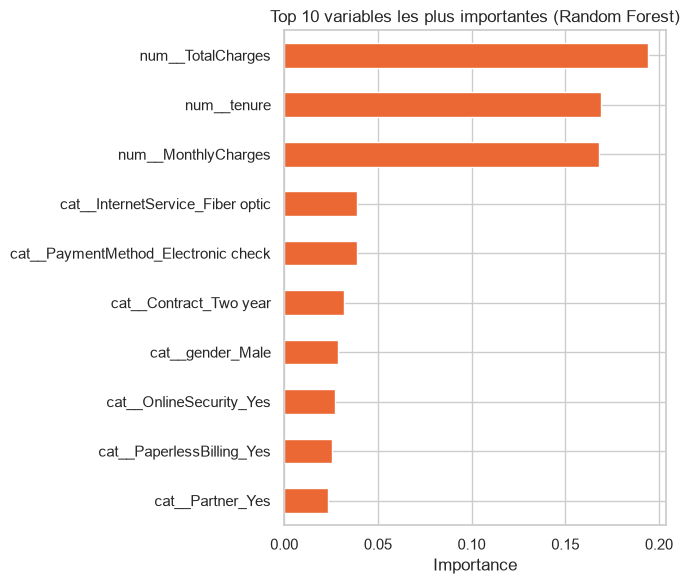

In [13]:
# --- Importance des variables selon le Random Forest ---
rf_interpretable = make_model(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
rf_interpretable.fit(X_train, y_train)

noms_colonnes = rf_interpretable.named_steps["prep"].get_feature_names_out()
importances_rf = pd.Series(
    rf_interpretable.named_steps["clf"].feature_importances_,
    index=noms_colonnes,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
importances_rf.head(10).plot(kind="barh", ax=ax, color=COULEUR_CHURN)
ax.invert_yaxis()
ax.set_title("Top 10 variables les plus importantes (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. Optimisation des hyperparamètres (GridSearchCV)

Recherche en grille sur `n_estimators`, `max_depth`, `min_samples_leaf` et
`class_weight`, avec l'AUC-ROC comme critère de sélection (validation croisée à 5 plis).

**Hyperparamètres retenus** : `class_weight="balanced"`, `max_depth=None`,
`min_samples_leaf=10`, `n_estimators=200`. **Résultat** : AUC 0,848 (meilleure de tous
les modèles testés) et surtout un rappel de 0,777 — nette amélioration par rapport à la
version par défaut (0,476), grâce à la pondération des classes qui compense le
déséquilibre 73,5 %/26,5 %. Ce compromis (rappel élevé, précision plus faible) est
cohérent avec le coût métier du churn : un client perdu coûte plus cher qu'une relance
inutile.

In [14]:
# --- Optimisation des hyperparamètres du Random Forest par recherche en grille ---
# Attention : ça va prendre 1 à 3 minutes selon ta machine (plusieurs centaines de forêts entraînées
# en validation croisée) - c'est normal, laisse tourner.
from sklearn.model_selection import GridSearchCV

grille = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [1, 5, 10],
    "clf__class_weight": [None, "balanced"],  # "balanced" compense le déséquilibre 73.5%/26.5%
}

rf_grid = GridSearchCV(
    make_model(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    param_grid=grille,
    scoring="roc_auc",   # critère principal de sélection, comme recommandé dans le manuel
    cv=cv,
    n_jobs=-1,
    verbose=1,            # affiche la progression, pour patienter tranquillement
)
rf_grid.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", rf_grid.best_params_)
print(f"Meilleur AUC (CV) : {rf_grid.best_score_:.3f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Meilleurs hyperparamètres : {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 200}
Meilleur AUC (CV) : 0.848


In [15]:
# --- Ajout du meilleur Random Forest au tableau comparatif ---
resultats.append(evaluer(rf_grid.best_estimator_, "Random Forest (optimisé)"))
pd.DataFrame(resultats)

,modèle,AUC,F1,précision,rappel,accuracy
0,Rég. logistique (L2),0.846 ± 0.013,0.593,0.653,0.543,0.802
1,Rég. logistique (L1),0.846 ± 0.012,0.593,0.653,0.544,0.802
2,SGD (perte logistique),0.836 ± 0.013,0.573,0.657,0.518,0.798
3,Arbre (sans limite),0.663 ± 0.017,0.504,0.500,0.508,0.734
4,Arbre (max_depth=5),0.829 ± 0.011,0.577,0.618,0.542,0.790
5,Random Forest (défaut),0.827 ± 0.012,0.544,0.637,0.476,0.789
6,Random Forest (optimisé),0.848 ± 0.011,0.633,0.534,0.777,0.761


## 8. Synthèse comparative et modèle retenu

**Modèle final retenu : Random Forest optimisé.** À capacité de discrimination égale
(AUC ≈ 0,846-0,848 pour les trois meilleurs modèles), il détecte largement plus de
churners réels que la régression logistique, ce qui prime compte tenu de l'asymétrie
des coûts d'erreur. La régression logistique reste une alternative plus simple à
expliquer, mentionnée comme second choix.

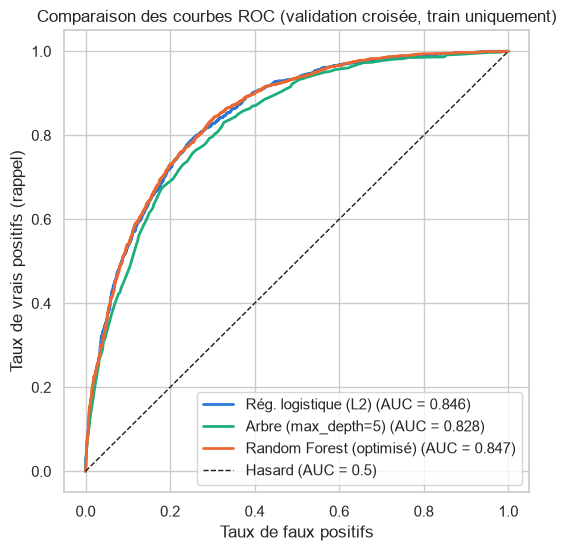

In [16]:
# --- Courbes ROC comparées, calculées "proprement" via validation croisée (out-of-fold) ---
# cross_val_predict avec method="predict_proba" donne, pour chaque client du train, une probabilité
# prédite par un modèle qui ne l'a JAMAIS vu pendant l'entraînement (comme en vrai test), sans jamais
# toucher au jeu de test réel.
from sklearn.model_selection import cross_val_predict

modeles_a_comparer = {
    "Rég. logistique (L2)": make_model(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "Arbre (max_depth=5)": make_model(DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    "Random Forest (optimisé)": rf_grid.best_estimator_,
}

# Palette : on réutilise les 3 premiers slots validés du système de couleurs (accessibles daltonisme)
couleurs_modeles = ["#2a78d6", "#1baf7a", "#eb6834"]

plt.figure(figsize=(6, 6))
for (nom, modele), couleur in zip(modeles_a_comparer.items(), couleurs_modeles):
    proba_oof = cross_val_predict(modele, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    fpr, tpr, _ = roc_curve(y_train, proba_oof)
    auc_oof = roc_auc_score(y_train, proba_oof)
    plt.plot(fpr, tpr, color=couleur, linewidth=2, label=f"{nom} (AUC = {auc_oof:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Hasard (AUC = 0.5)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (rappel)")
plt.title("Comparaison des courbes ROC (validation croisée, train uniquement)")
plt.legend()
plt.show()

## 9. Sauvegarde du modèle final

Le pipeline complet (préprocessing + Random Forest optimisé) est sauvegardé avec
`joblib`, ainsi que les hyperparamètres et le score de validation croisée, pour être
repris dans le notebook de validation sans avoir à tout réentraîner.

In [17]:
# --- Sauvegarde du modèle final retenu, pour le notebook de validation ---
import joblib

modele_final = rf_grid.best_estimator_  # pipeline complet : préprocessing + Random Forest optimisé

joblib.dump(modele_final, "../models/random_forest_final.pkl")

# On sauvegarde aussi les infos de la validation croisée, pour ne pas les ressaisir "en dur"
# dans le notebook de validation (traçabilité complète)
import json
meta = {
    "best_params": rf_grid.best_params_,
    "cv_auc_mean": rf_grid.best_score_,
}
with open("../models/random_forest_final_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Modèle et métadonnées sauvegardés dans models/")

Modèle et métadonnées sauvegardés dans models/
